SUBGRAPH A

In [1]:
from typing_extensions import TypedDict
from langchain_openai import ChatOpenAI
from langgraph.graph import StateGraph,START,END
from dotenv import load_dotenv

In [3]:
load_dotenv()

True

In [4]:
class SubState(TypedDict):
    input_text:str
    translated_text:str


In [5]:
subgraph_llm=ChatOpenAI(model='gpt-4o')

In [8]:
def translate_text(state:SubState):
    prompt=f"""Translate the following text to Hindi.
Keep it natural and clear. Do not add extra content.
Text:{state["input_text"]}
""".strip()
    translated_text=subgraph_llm.invoke(prompt).content
    return{'translated_text',translated_text}

In [10]:
subgraph_builder=StateGraph(SubState)
subgraph_builder.add_node('translate_text',translate_text)
subgraph_builder.add_edge(START,'translate_text')
subgraph_builder.add_edge('translate_text',END)
subgraph=subgraph_builder.compile()


In [11]:
class ParentState(TypedDict):
    question:str
    eng_ans:str
    hindi_ans:str

In [12]:
parent_llm = ChatOpenAI(model='gpt-4o-mini')

In [13]:
def answer(state:ParentState):
    prompt=f"""generate an english answer for the question Text:{state['question']}"""
    answer_eng=parent_llm.invoke(prompt).content
    return('eng_ans',answer_eng)

In [14]:
def translate(state:ParentState):
    result=subgraph.invoke({'input_text':state['eng_ans']})
    return {'answer_hin': result['translated_text']}


In [15]:
parent_builder=StateGraph(ParentState)
parent_builder.add_node('answer',answer)
parent_builder.add_node('translate',translate)
parent_builder.add_edge(START, 'answer')
parent_builder.add_edge('answer', 'translate')
parent_builder.add_edge('translate', END)

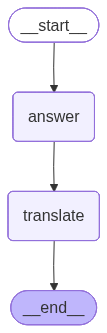

In [16]:
graph = parent_builder.compile()

graph


In [17]:
graph.invoke({'question': 'What is quantum physics'})

RateLimitError: Error code: 429 - {'error': {'message': 'You exceeded your current quota, please check your plan and billing details. For more information on this error, read the docs: https://platform.openai.com/docs/guides/error-codes/api-errors.', 'type': 'insufficient_quota', 'param': None, 'code': 'insufficient_quota'}}